In [12]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [13]:
df = ev.build_results("results")

/Users/s.franke/Development/master_clean/experiments/evaluation.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df.apply(calc_row, axis=1, args=(err_col, conf_col))


In [14]:
df.to_csv("results_4.csv", index=False)

In [15]:
df.max()

A                 3.00
A_1               3.00
A_1_conf          0.90
A_1_conf_error    3.72
A_1_error         9.00
                  ... 
E_5_error         4.00
E_6               3.00
E_6_conf          0.97
E_6_conf_error    3.20
E_6_error         4.00
Length: 125, dtype: float64

In [16]:
df

,A,A_1,A_1_conf,A_1_conf_error,A_1_error,A_2,A_2_conf,A_2_conf_error,A_2_error,A_3,...,E_4_conf_error,E_4_error,E_5,E_5_conf,E_5_conf_error,E_5_error,E_6,E_6_conf,E_6_conf_error,E_6_error
call_nr,,,,,,,,,,,,,,,,,,,,,
1,1,1,0.74,0.26,0,1,0.74,0.26,0,1,...,0.30,0,1,0.70,0.30,0,1,0.70,0.30,0
2,1,1,0.62,0.38,0,1,0.72,0.28,0,1,...,0.20,0,1,0.80,0.20,0,1,0.80,0.20,0
3,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,0.40,0,1,0.60,0.40,0,1,0.60,0.40,0
4,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,0.90,1,0,0.90,0.90,1,0,0.90,0.90,1
5,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,1.40,2,1,0.70,1.40,2,1,0.70,1.40,2
6,3,0,0.35,3.15,9,3,0.74,0.26,0,0,...,0.60,0,0,0.40,0.60,0,0,0.40,0.60,0
7,3,3,0.78,0.22,0,3,0.78,0.22,0,3,...,0.05,0,2,0.85,2.55,3,3,0.92,0.08,0
8,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,2.46,3,2,0.82,2.46,3,2,0.82,2.46,3
9,3,2,0.72,2.16,3,2,0.72,2.16,3,2,...,0.40,0,1,0.60,0.40,0,1,0.70,0.30,0


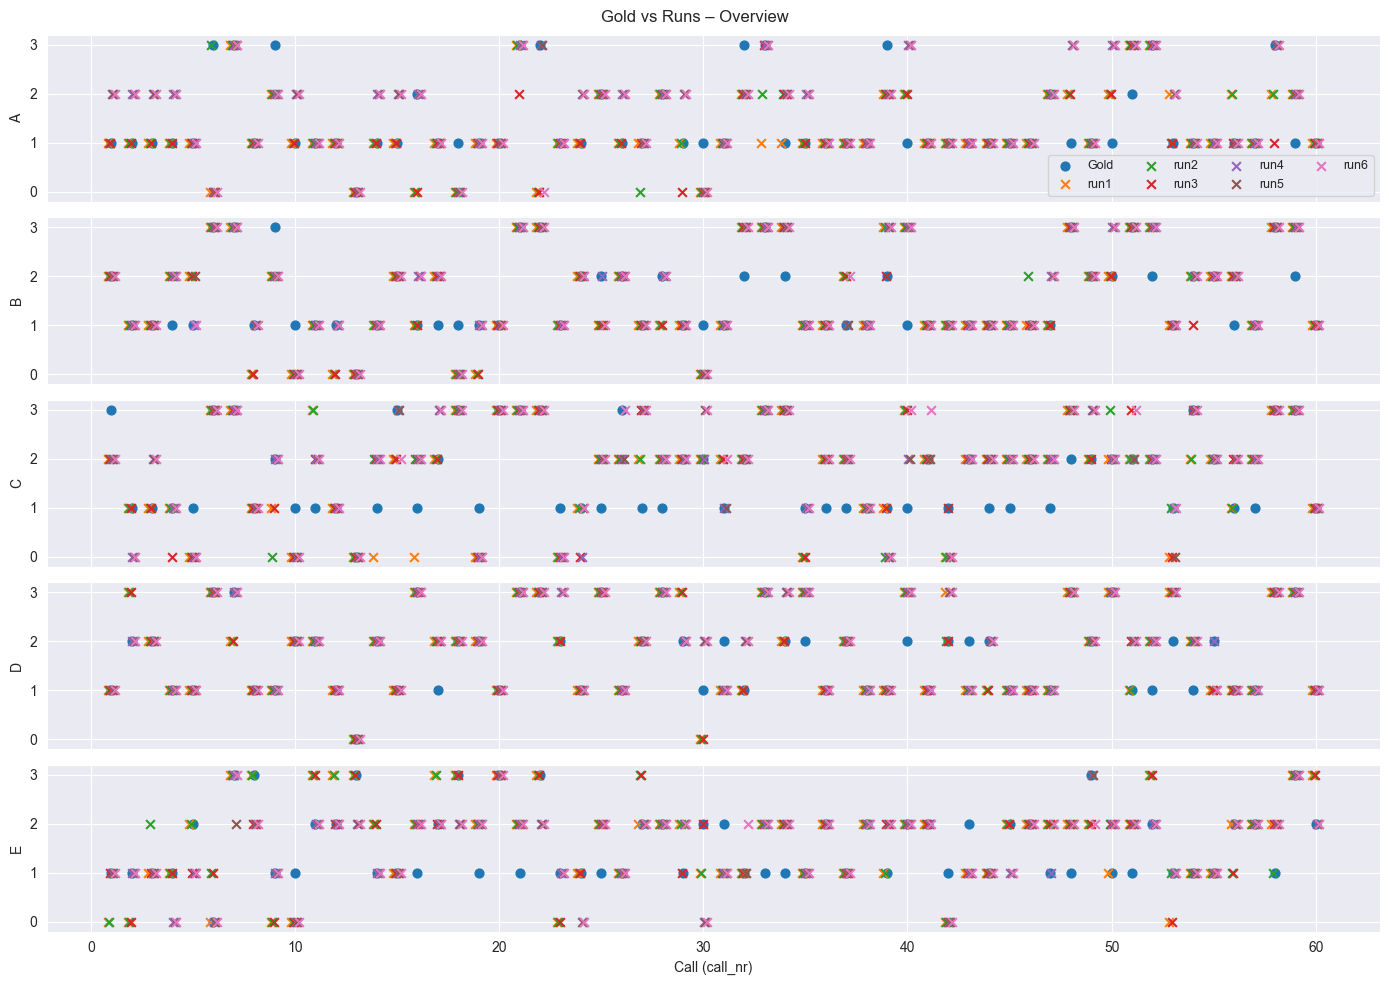

In [17]:
long_df = ev.wide_to_long_runs(df)
ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

In [18]:
long_df.to_csv("long_results_4.csv", index=False)

In [6]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,conf_error,1,A,60,0.643167,0.360,38.59,1.034913
1,conf_error,1,B,60,0.445833,0.260,26.75,0.669752
2,conf_error,1,C,60,0.593167,0.380,35.59,0.829891
3,conf_error,1,D,60,0.434667,0.260,26.08,0.634342
4,conf_error,1,E,60,0.545167,0.380,32.71,0.658368
5,conf_error,2,A,60,0.548333,0.330,32.90,0.809382
6,conf_error,2,B,60,0.452500,0.260,27.15,0.672757
7,conf_error,2,C,60,0.619833,0.380,37.19,0.861711
8,conf_error,2,D,60,0.413333,0.260,24.80,0.613821
9,conf_error,2,E,60,0.571000,0.500,34.26,0.683625


In [7]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.643167,0.445833,0.593167,0.434667,0.545167
2,0.548333,0.452500,0.619833,0.413333,0.571000
3,0.653333,0.462000,0.570500,0.418500,0.576500
4,0.658500,0.419833,0.502667,0.370167,0.633500
5,0.669000,0.432500,0.501833,0.395500,0.686167
6,0.703333,0.433167,0.533000,0.393167,0.687833


In [8]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.816667,0.433333,0.666667,0.350000,0.550000
2,0.633333,0.450000,0.716667,0.333333,0.616667
3,0.816667,0.450000,0.666667,0.350000,0.633333
4,0.733333,0.333333,0.566667,0.266667,0.666667
5,0.733333,0.383333,0.583333,0.300000,0.733333
6,0.883333,0.383333,0.650000,0.300000,0.750000


In [9]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,conf_error,1,300,0.532400,159.72,3.72
1,conf_error,2,300,0.521000,156.30,2.70
2,conf_error,3,300,0.536167,160.85,4.08
3,conf_error,4,300,0.516933,155.08,4.50
4,conf_error,5,300,0.537000,161.10,4.50
5,conf_error,6,300,0.550100,165.03,4.50
6,error,1,300,0.563333,169.00,9.00
7,error,2,300,0.550000,165.00,9.00
8,error,3,300,0.583333,175.00,9.00
9,error,4,300,0.513333,154.00,9.00


In [10]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,169,159.72
1,2,165,156.30
2,3,175,160.85
3,4,154,155.08
4,5,164,161.10
5,6,178,165.03


In [11]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.769444,277,0.645944,232.54
1,B,0.405556,146,0.440972,158.75
2,C,0.641667,231,0.553500,199.26
3,D,0.316667,114,0.404222,145.52
4,E,0.658333,237,0.616694,222.01


In [4]:
(df == 9).sum()

A                 0
A_1               0
A_1_conf          0
A_1_conf_error    0
A_1_error         2
                 ..
E_5_error         0
E_6               0
E_6_conf          0
E_6_conf_error    0
E_6_error         0
Length: 125, dtype: int64

In [7]:
df

,A,A_1,A_1_conf,A_1_conf_error,A_1_error,A_2,A_2_conf,A_2_conf_error,A_2_error,A_3,...,E_4_conf_error,E_4_error,E_5,E_5_conf,E_5_conf_error,E_5_error,E_6,E_6_conf,E_6_conf_error,E_6_error
call_nr,,,,,,,,,,,,,,,,,,,,,
1,1,1,0.74,0.26,0,1,0.74,0.26,0,1,...,0.30,0,1,0.70,0.30,0,1,0.70,0.30,0
2,1,1,0.62,0.38,0,1,0.72,0.28,0,1,...,0.20,0,1,0.80,0.20,0,1,0.80,0.20,0
3,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,0.40,0,1,0.60,0.40,0,1,0.60,0.40,0
4,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,0.90,1,0,0.90,0.90,1,0,0.90,0.90,1
5,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,1.40,2,1,0.70,1.40,2,1,0.70,1.40,2
6,3,0,0.35,3.15,9,3,0.74,0.26,0,0,...,0.60,0,0,0.40,0.60,0,0,0.40,0.60,0
7,3,3,0.78,0.22,0,3,0.78,0.22,0,3,...,0.05,0,2,0.85,2.55,3,3,0.92,0.08,0
8,1,1,0.62,0.38,0,1,0.62,0.38,0,1,...,2.46,3,2,0.82,2.46,3,2,0.82,2.46,3
9,3,2,0.72,2.16,3,2,0.72,2.16,3,2,...,0.40,0,1,0.60,0.40,0,1,0.70,0.30,0


In [15]:
import tiktoken


OUTPUT_CONTRACT_DEFAULT = """
Return ONLY valid JSON (no markdown, no commentary).

Schema:
{
  "A": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "B": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "C": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "D": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "E": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>}
}
""".strip()

guidelines =Path("guidelines/a_guidelines.md").read_text(encoding="utf-8")

text = guidelines + "\n\n" + OUTPUT_CONTRACT_DEFAULT


## Token zählen: 


encoding = tiktoken.get_encoding("o200k_base")

tokens = encoding.encode(text)

print("GPT 5.2:" , len(tokens))

GPT 5.2: 461


In [16]:
import anthropic
import pandas as pd
import requests
from dotenv import load_dotenv
from anthropic import Anthropic
import os

load_dotenv()
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
client = anthropic.Anthropic()

response = client.messages.count_tokens(
    model="claude-opus-4-6",
    messages=[{"role": "user", "content": text}],
)

print(response.json())

{"input_tokens":533}


/var/folders/9k/bqn5d5t90kl0x7z66fx4d0cw0000gn/T/ipykernel_23674/1825925790.py:17: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(response.json())


In [18]:
5 * 530

2650